In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import scipy

import os

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

import warnings
warnings.simplefilter("ignore", UserWarning)

from tqdm import tqdm

In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=120)

In [4]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


# Variables

In [5]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'

In [8]:
!ls -lh {data_object_dir}

total 28G
-rwxrwx---+ 1 kk837 kk837 4.8G Feb 10 12:22 all_b2c_cells_filtered_celltype-sel_raw.h5ad
-rwxrwx---+ 1 kk837 kk837 4.6G Feb 10 12:23 all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad
-rwxrwx---+ 1 kk837 kk837 5.5G Mar 27 09:34 all_b2c_cells_filtered_niche-sel_raw.h5ad
-rwxrwx---+ 1 kk837 kk837 5.6G Mar  6 23:59 all_b2c_cells_filtered_raw.h5ad
-rwxrwx---+ 1 kk837 kk837 4.8G Nov 17 21:39 all_b2c_cells_raw.h5ad
drwxrwx---+ 6 kk837 kk837  277 Nov 17 21:25 archive_17Nov2025
drwxrwx---+ 2 kk837 kk837  180 Feb 18 00:57 cellcharter_autok
drwxrwx---+ 3 kk837 kk837  371 Feb 19 22:11 cellcharter_cluster_subsets
-rwxrwx---+ 1 kk837 kk837 3.4G Dec  9 11:54 epicardium-mixture_b2c_cells_filtered_raw.h5ad
-rwxrwx---+ 1 kk837 kk837 3.0G Dec  9 17:07 erythrocytes_b2c_cells_filtered_raw.h5ad
drwxrwx---+ 4 kk837 kk837   58 Nov 17 22:37 scVI
-rwxrwx---+ 1 kk837 kk837  94M Feb 24 23:00 sd_hd_pseudobulk_section-donor-niche_sum.h5ad
drwxrwx---+ 3 kk837 kk837  385 Feb 10 06:37 TACCO
-rwxrw

# Read in original adata

In [7]:
%%time
adata = sc.read_h5ad(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad')
adata

CPU times: user 507 ms, sys: 887 ms, total: 1.39 s
Wall time: 22.1 s


AnnData object with n_obs × n_vars = 213873 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'coarse_grain_tacco_ref-hd-scn_colors'
    varm: 'rec_ref-HD-SCN'

# Add scVI latent space

In [8]:
filename_header = 'post-tacco_correcting-donor_'
latent_file_name_list = os.listdir(f'{data_object_dir}/scVI/latent_variables')
latent_file_name_list = [x.split('.h5ad')[0] for x in latent_file_name_list if (x!='archive')&(filename_header in x)]
latent_file_name_list

['post-tacco_correcting-donor_n-layers-3']

In [9]:
for latent_file_name in latent_file_name_list:
    latent_space_condition = latent_file_name.split(filename_header)[1]
    latent = sc.read_h5ad(f'{data_object_dir}/scVI/latent_variables/{latent_file_name}.h5ad')
    # add latent space
    adata.obsm[f'scVI_latent_{latent_space_condition}']=latent.X.copy()

In [10]:
adata

AnnData object with n_obs × n_vars = 213873 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'coarse_grain_tacco_ref-hd-scn_colors'
    obsm: 'scVI_latent_n-layers-3'
    varm: 'rec_ref-HD-SCN'

# Find neighbors, UMAP

In [11]:
latent_file_name_list.sort()
latent_file_name_list

['post-tacco_correcting-donor_n-layers-3']

##### n-layers-3 #####


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


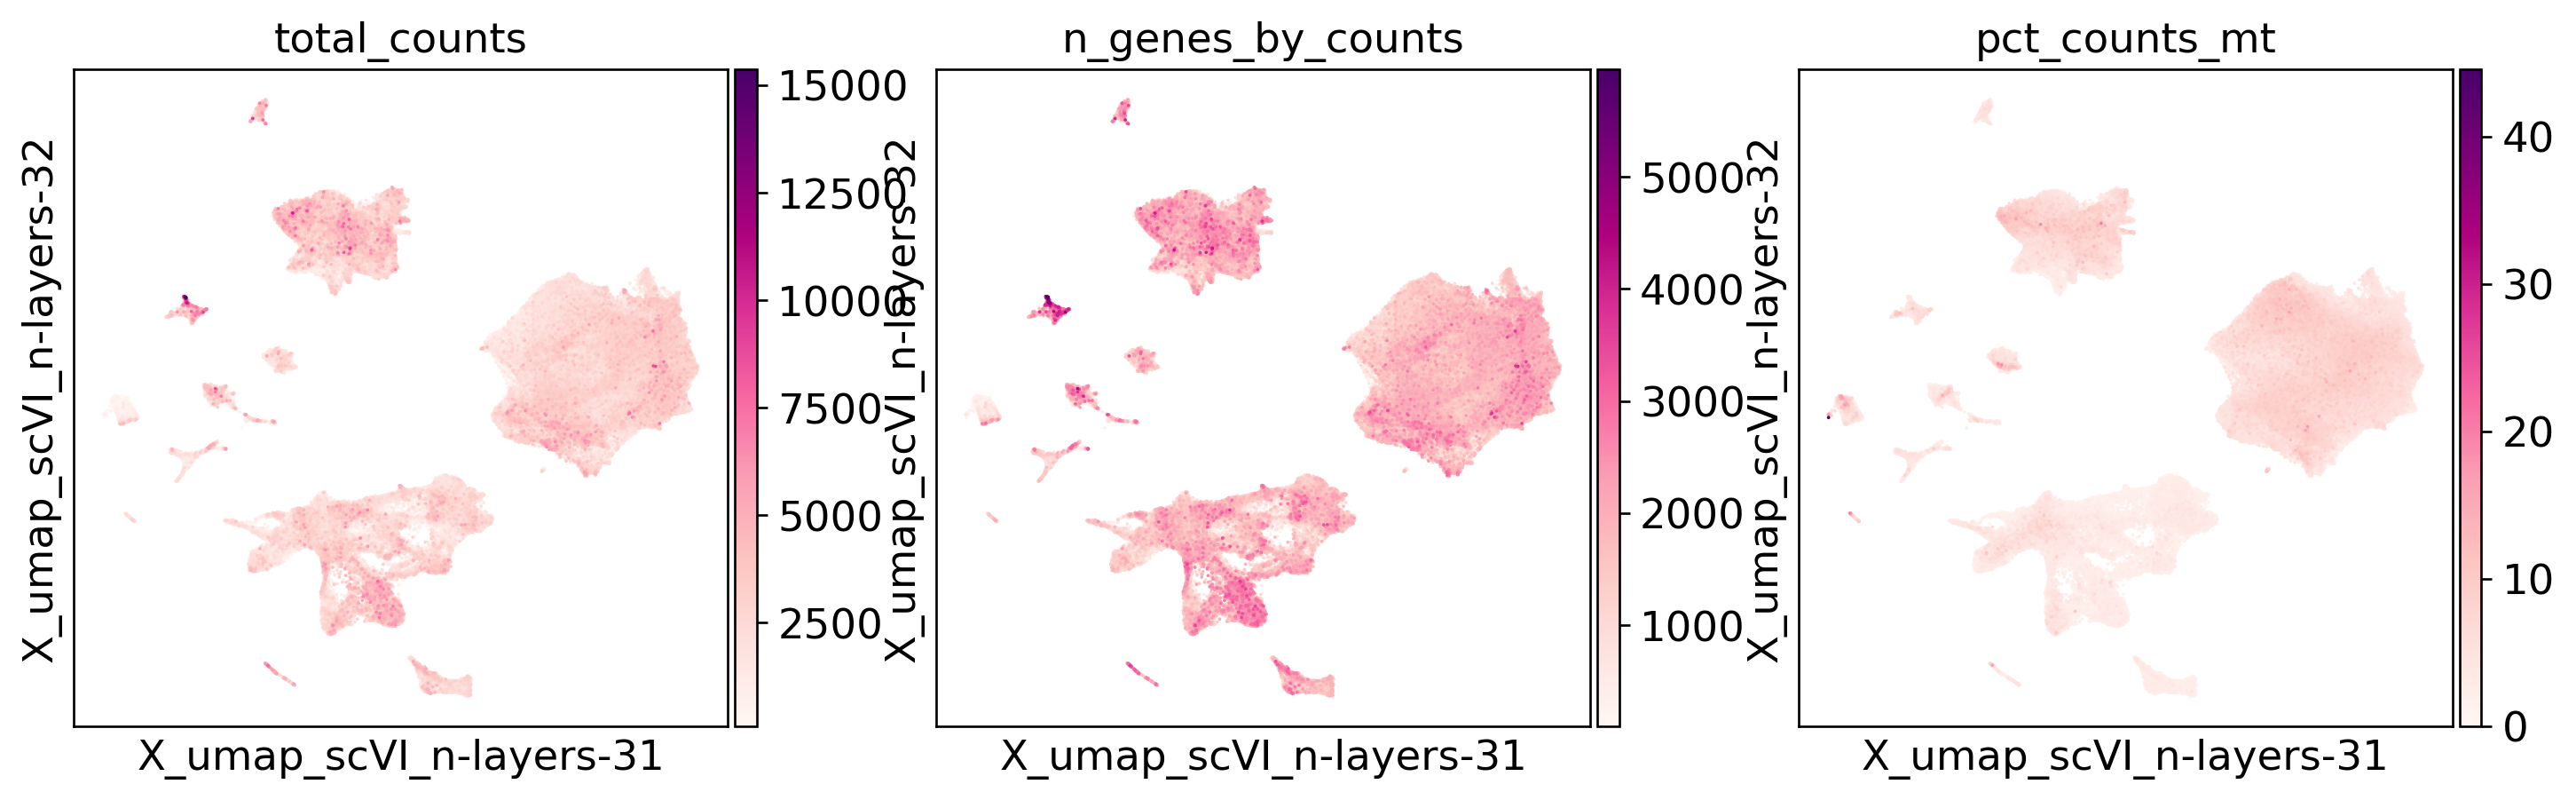

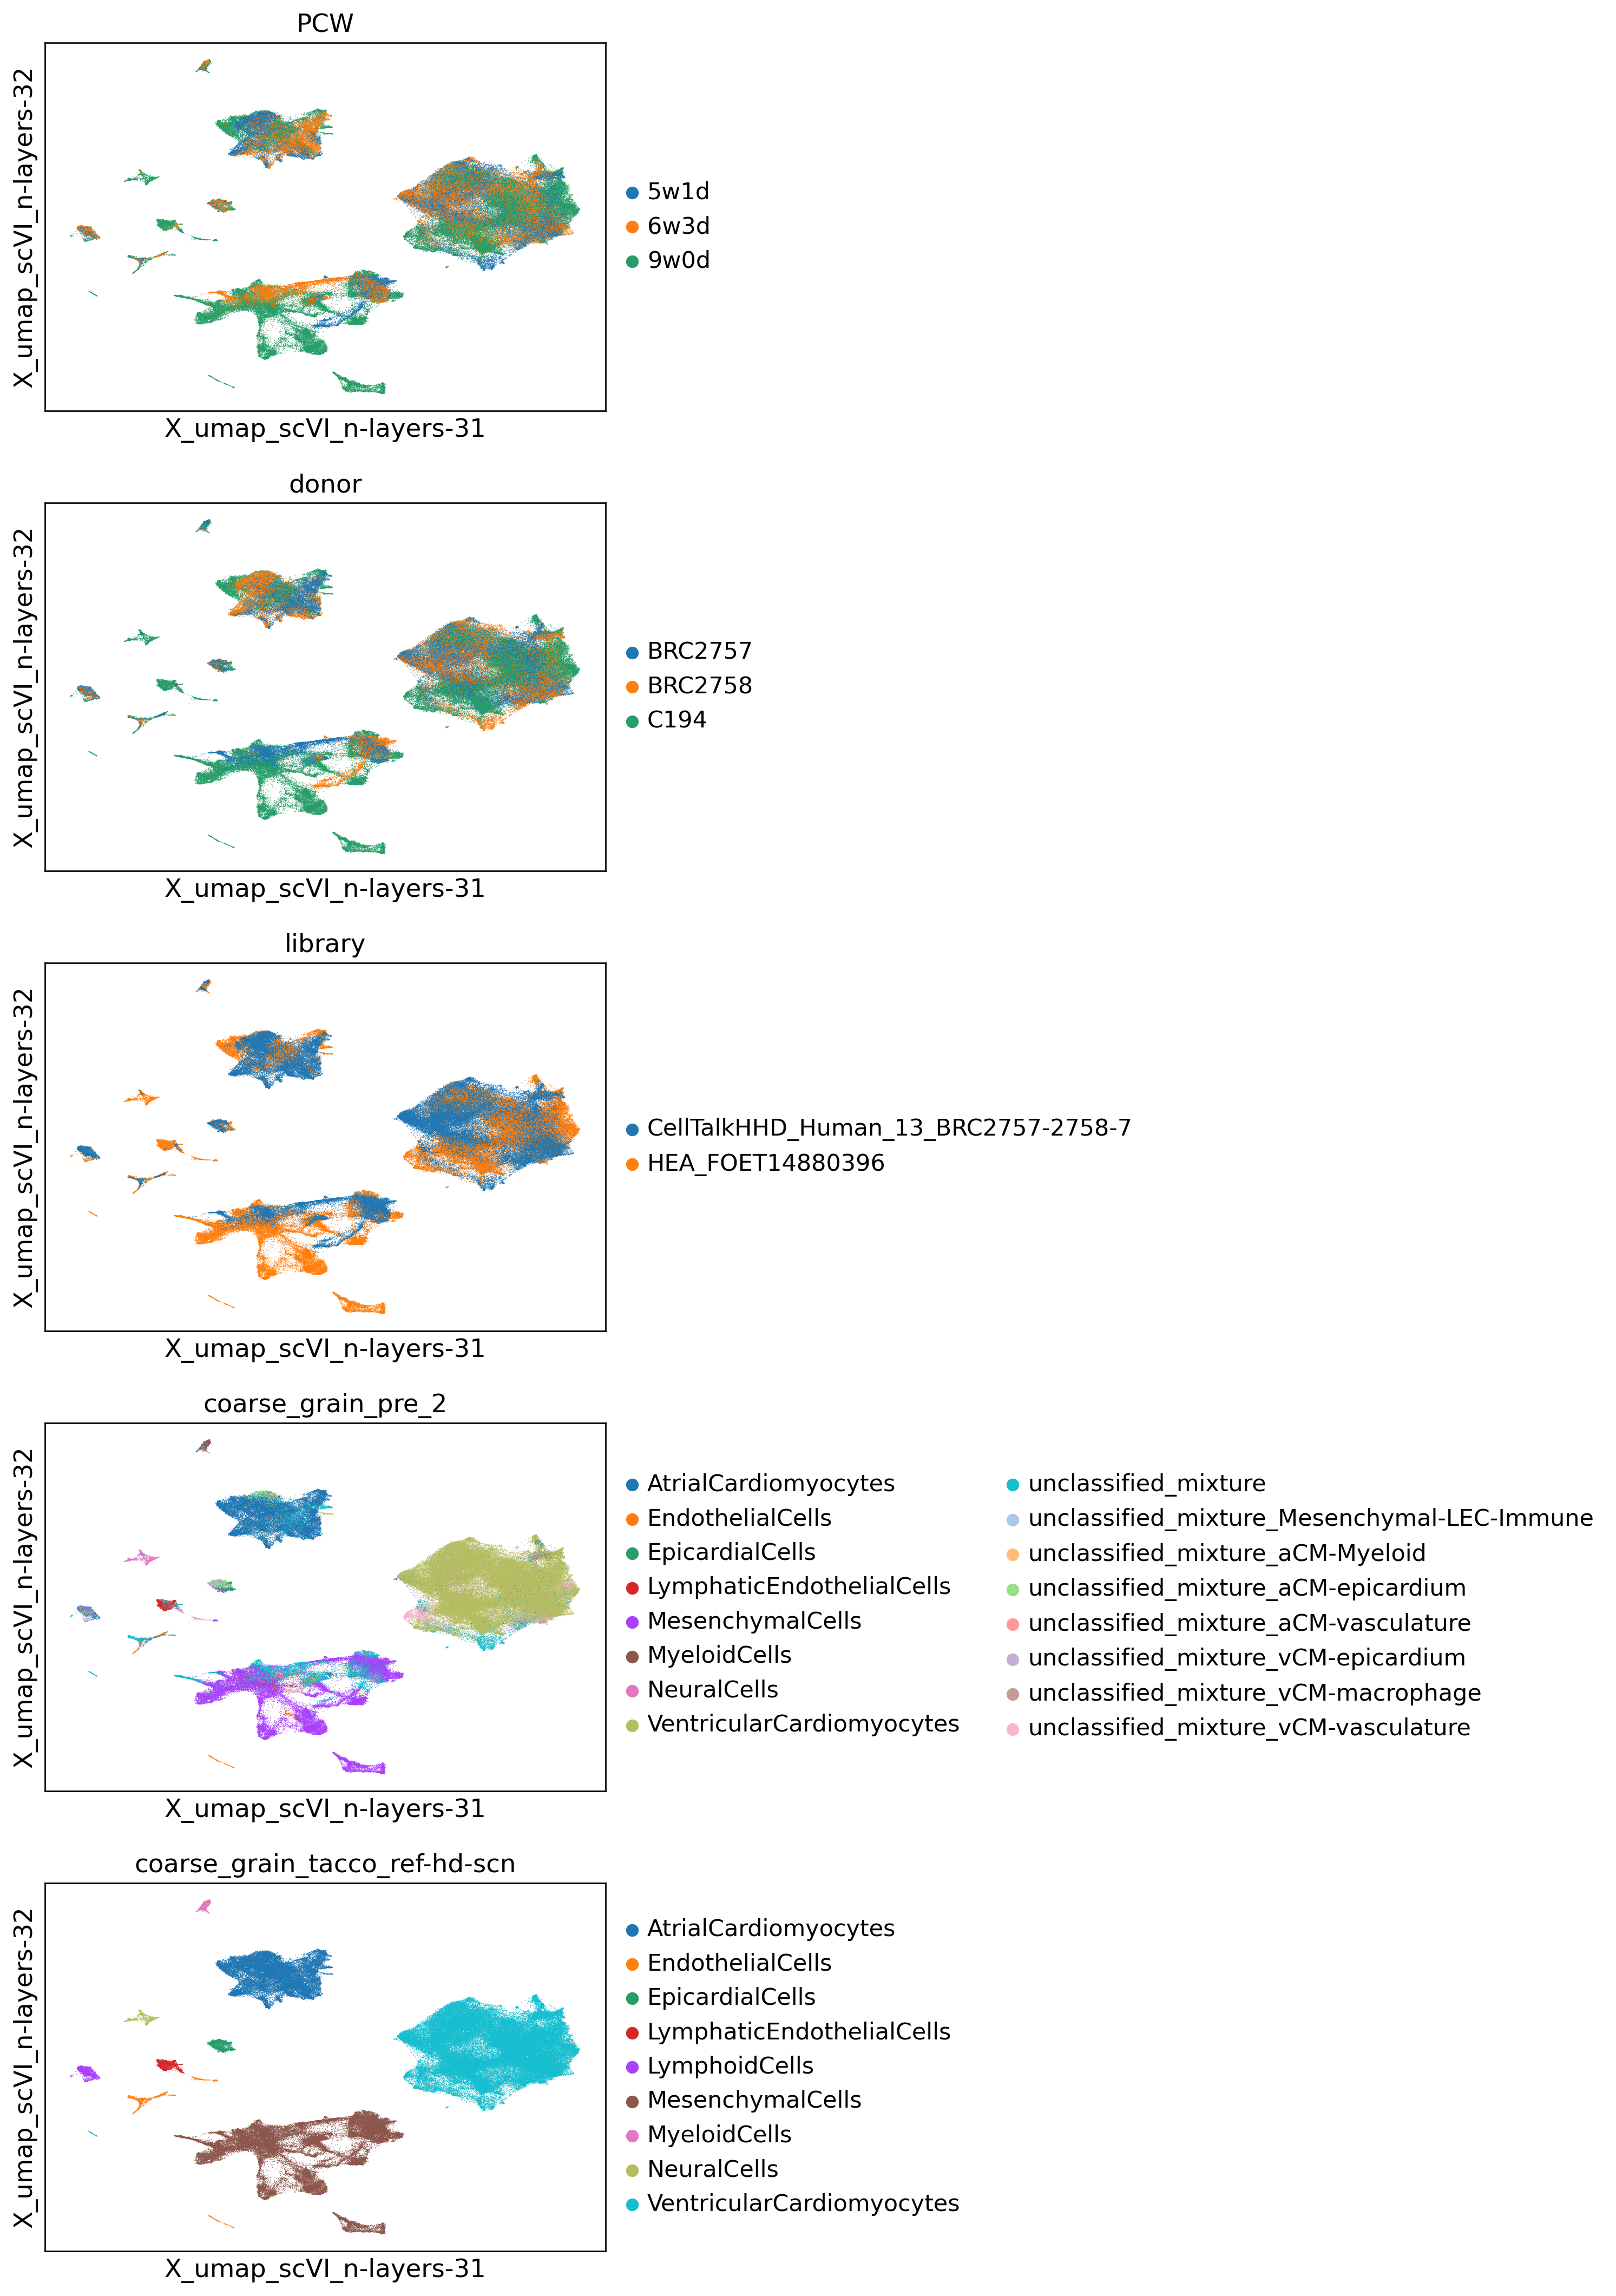



CPU times: user 9min 25s, sys: 737 ms, total: 9min 25s
Wall time: 4min 46s


In [12]:
%%time
for latent_file_name in latent_file_name_list:
    latent_space_condition = latent_file_name.split(filename_header)[1]
    print(f'##### {latent_space_condition} #####')
    sc.pp.neighbors(adata, use_rep=f'scVI_latent_{latent_space_condition}',n_neighbors=15)
    sc.tl.umap(adata, min_dist=0.2, spread=1.0)# 
    adata.obsm[f'X_umap_scVI_{latent_space_condition}'] = adata.obsm['X_umap'].copy()
    del adata.obsm['X_umap']
    # check batches
    sc.pl.embedding(adata, basis=f'X_umap_scVI_{latent_space_condition}',
                color=['total_counts','n_genes_by_counts',"pct_counts_mt"], 
           size=5, wspace=0.2, ncols=6, components='all',cmap='RdPu')

    sc.pl.embedding(adata,basis=f'X_umap_scVI_{latent_space_condition}',
                    color=['PCW','donor','library','coarse_grain_pre_2','coarse_grain_tacco_ref-hd-scn'],wspace=0.5,
                    ncols=1
                   )
    print('')
    print('')

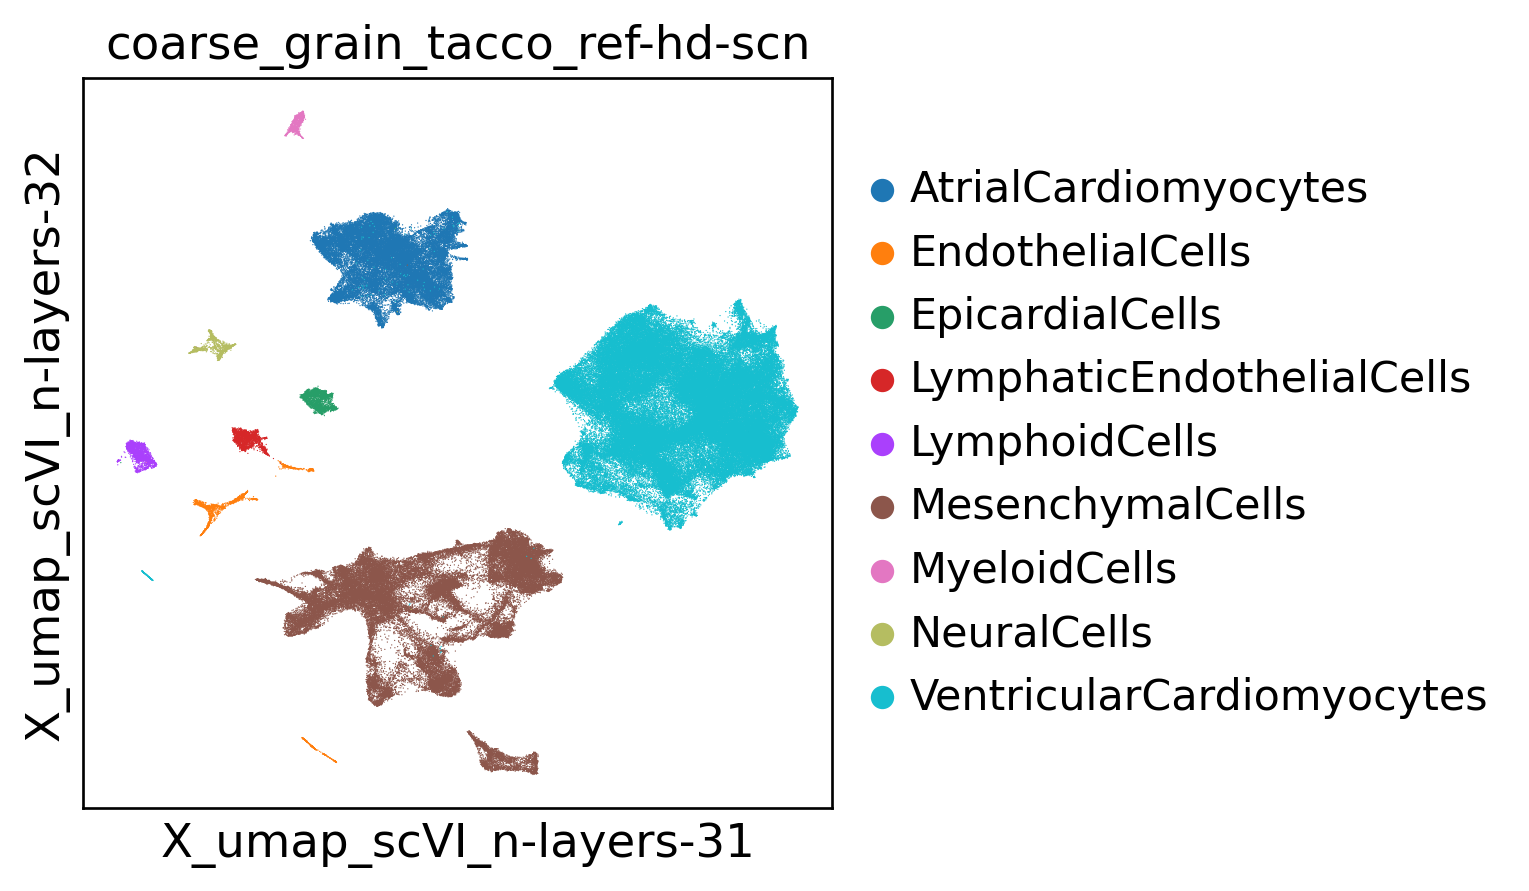

In [13]:
sc.pl.embedding(adata,basis=f'X_umap_scVI_{latent_space_condition}',
                    color=['coarse_grain_tacco_ref-hd-scn'],wspace=0.5,
                    ncols=1
                   )

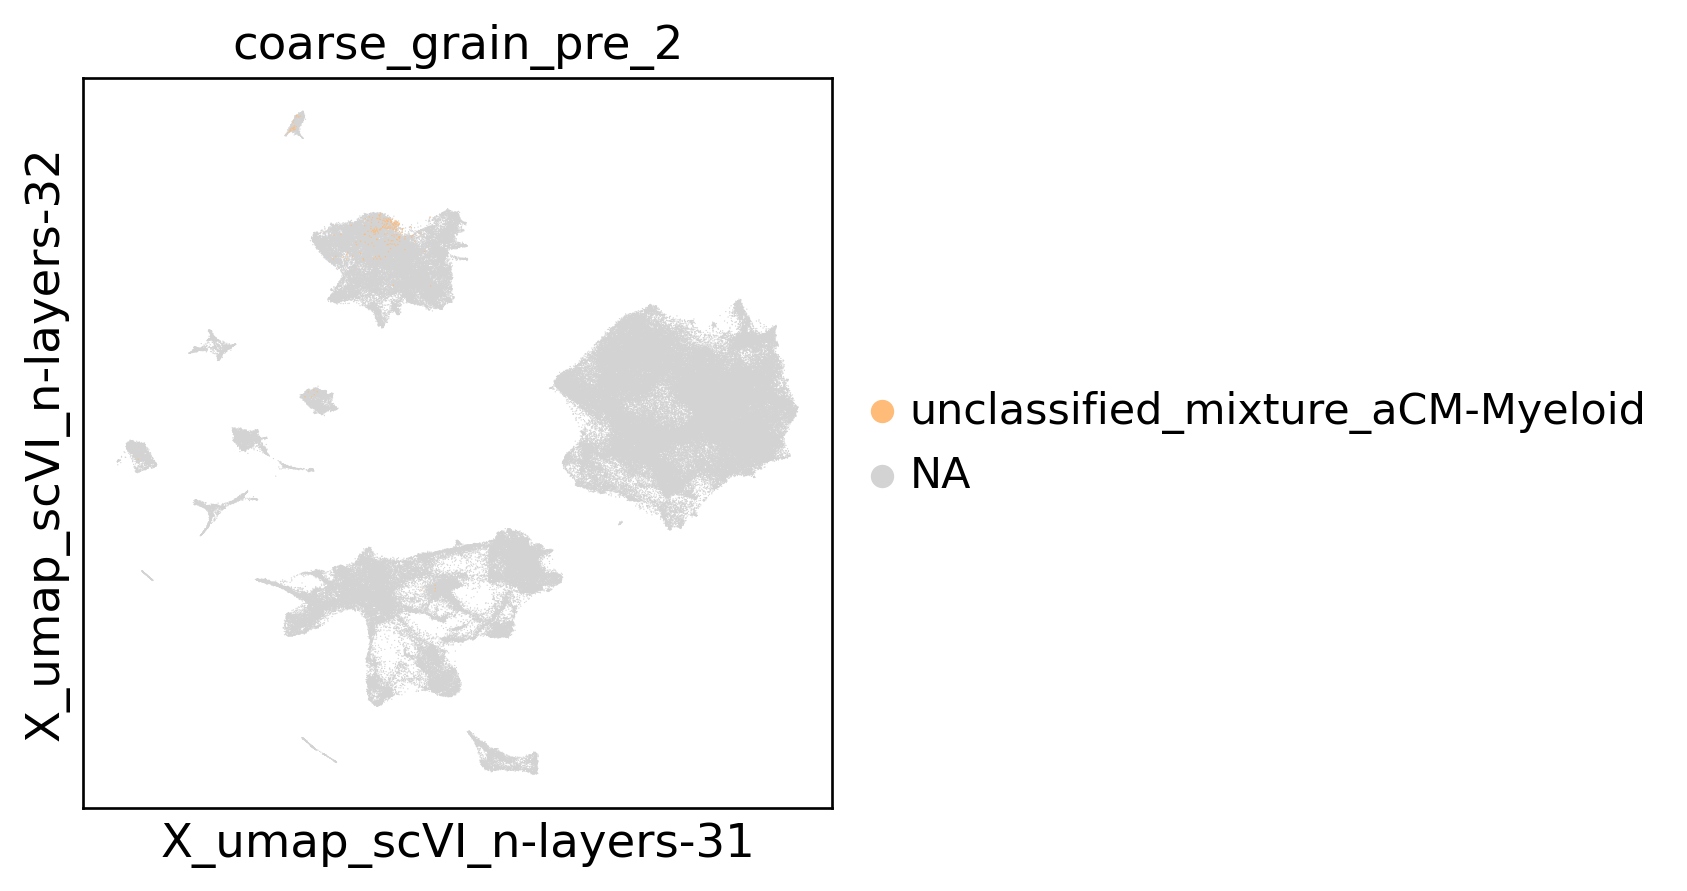

In [15]:
sc.pl.embedding(adata,basis=f'X_umap_scVI_{latent_space_condition}',
                    color=['coarse_grain_pre_2'],groups=['unclassified_mixture_aCM-Myeloid'],
                    ncols=1
                   )

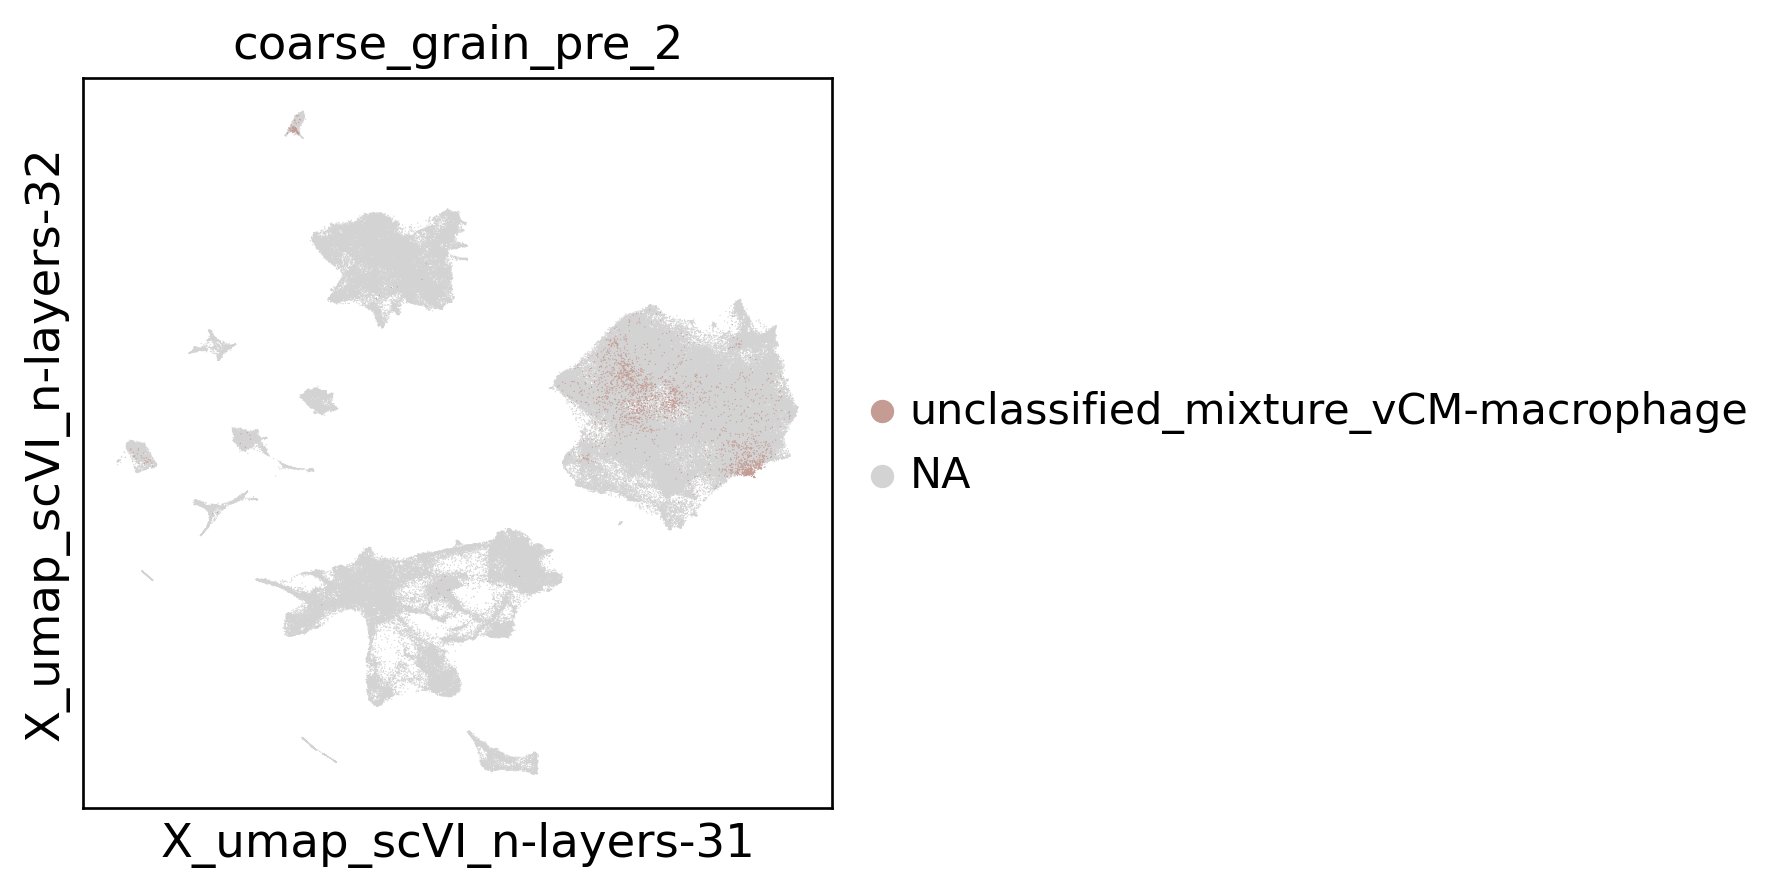

In [16]:
sc.pl.embedding(adata,basis=f'X_umap_scVI_{latent_space_condition}',
                    color=['coarse_grain_pre_2'],groups=['unclassified_mixture_vCM-macrophage'],
                    ncols=1
                   )

# Save

In [17]:
%%time
adata.write(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad')
adata

CPU times: user 668 ms, sys: 1.17 s, total: 1.83 s
Wall time: 24.9 s


AnnData object with n_obs × n_vars = 213873 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'coarse_grain_tacco_ref-hd-scn_colors', 'neighbors', 'umap', 'PCW_colors', 'donor_colors', 'library_colors', 'coarse_grain_pre_2_color

In [19]:
adata.X.data[:5]

array([1., 1., 1., 1., 1.])

# Save per group

In [21]:
data_object_dir

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'

In [23]:
set(adata.obs['coarse_grain_tacco_ref-hd-scn'])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes'}

In [26]:
os.makedirs(f'{data_object_dir}/TACCO/coarse_grain_subsets', exist_ok=True)

for group in ['AtrialCardiomyocytes',
             'EndothelialCells',
             'EpicardialCells',
             # 'LymphaticEndothelialCells',
             'LymphoidCells',
             'MesenchymalCells',
             'MyeloidCells',
             'NeuralCells',
             'VentricularCardiomyocytes'
             ]:
    print(group)
    adata_sub = adata[adata.obs['coarse_grain_tacco_ref-hd-scn']==group]
    print(adata_sub.shape)
    adata_sub.write(f'{data_object_dir}/TACCO/coarse_grain_subsets/b2c_cells_{group}_raw.h5ad')
    del adata_sub

AtrialCardiomyocytes
(34193, 18077)
EndothelialCells
(2878, 18077)
EpicardialCells
(2399, 18077)
LymphoidCells
(2289, 18077)
MesenchymalCells
(52703, 18077)
MyeloidCells
(1203, 18077)
NeuralCells
(1501, 18077)
VentricularCardiomyocytes
(114538, 18077)


# Plots for manuscript

In [50]:
adata_pre_tacco = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
# remove certain cell types which didn't go to TACCO process
adata_pre_tacco = adata_pre_tacco[adata_pre_tacco.obs['coarse_grain_pre_2'].isin(['Erythrocytes',
                                                    'EpithelialCells',
                                                    'Megakaryocytes'
                                                   ])==False]
print(adata_pre_tacco)
print('')
adata_post_tacco = sc.read_h5ad(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad')
print(adata_post_tacco)

View of AnnData object with n_obs × n_vars = 217420 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_r

--> the cell number of post-tacco data is smaller than pre-tacco, since there are cells which was removed at the re-QC step after TACCO's splitting count step

In [51]:
set(adata_post_tacco.obs['coarse_grain_tacco_ref-hd-scn'])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes'}

In [52]:
new_labels = ['unclassified_mixture' if 'unclassified_mixture' in x else x \
              for x in adata_pre_tacco.obs['coarse_grain_pre_2']]
adata_pre_tacco.obs['coarse_grain_pre_2_mod'] = new_labels.copy()

new_labels = ['unclassified_mixture' if 'unclassified_mixture' in x else x \
              for x in adata_post_tacco.obs['coarse_grain_pre_2']]
adata_post_tacco.obs['coarse_grain_pre_2_mod'] = new_labels.copy()

In [53]:
celltype_order = [
    'AtrialCardiomyocytes',
    'VentricularCardiomyocytes',
    'MesenchymalCells',
    'EndothelialCells',
    'LymphaticEndothelialCells',
    'EpicardialCells',
    'NeuralCells',
    'MyeloidCells', 
    'unclassified_mixture'
]

adata_pre_tacco.obs['coarse_grain_pre_2_mod'] = pd.Categorical(
    adata_pre_tacco.obs['coarse_grain_pre_2_mod'],
    categories=celltype_order,
    ordered=True
)
adata_post_tacco.obs['coarse_grain_pre_2_mod'] = pd.Categorical(
    adata_post_tacco.obs['coarse_grain_pre_2_mod'],
    categories=celltype_order,
    ordered=True
)
adata_post_tacco.obs['coarse_grain_tacco_ref-hd-scn'] = pd.Categorical(
    adata_post_tacco.obs['coarse_grain_tacco_ref-hd-scn'],
    categories=[
        'AtrialCardiomyocytes',
        'VentricularCardiomyocytes',
        'MesenchymalCells',
        'EndothelialCells',
        'LymphaticEndothelialCells',
        'EpicardialCells',
        'NeuralCells',
        'MyeloidCells', 
        'LymphoidCells'
    ],
    ordered=True
)


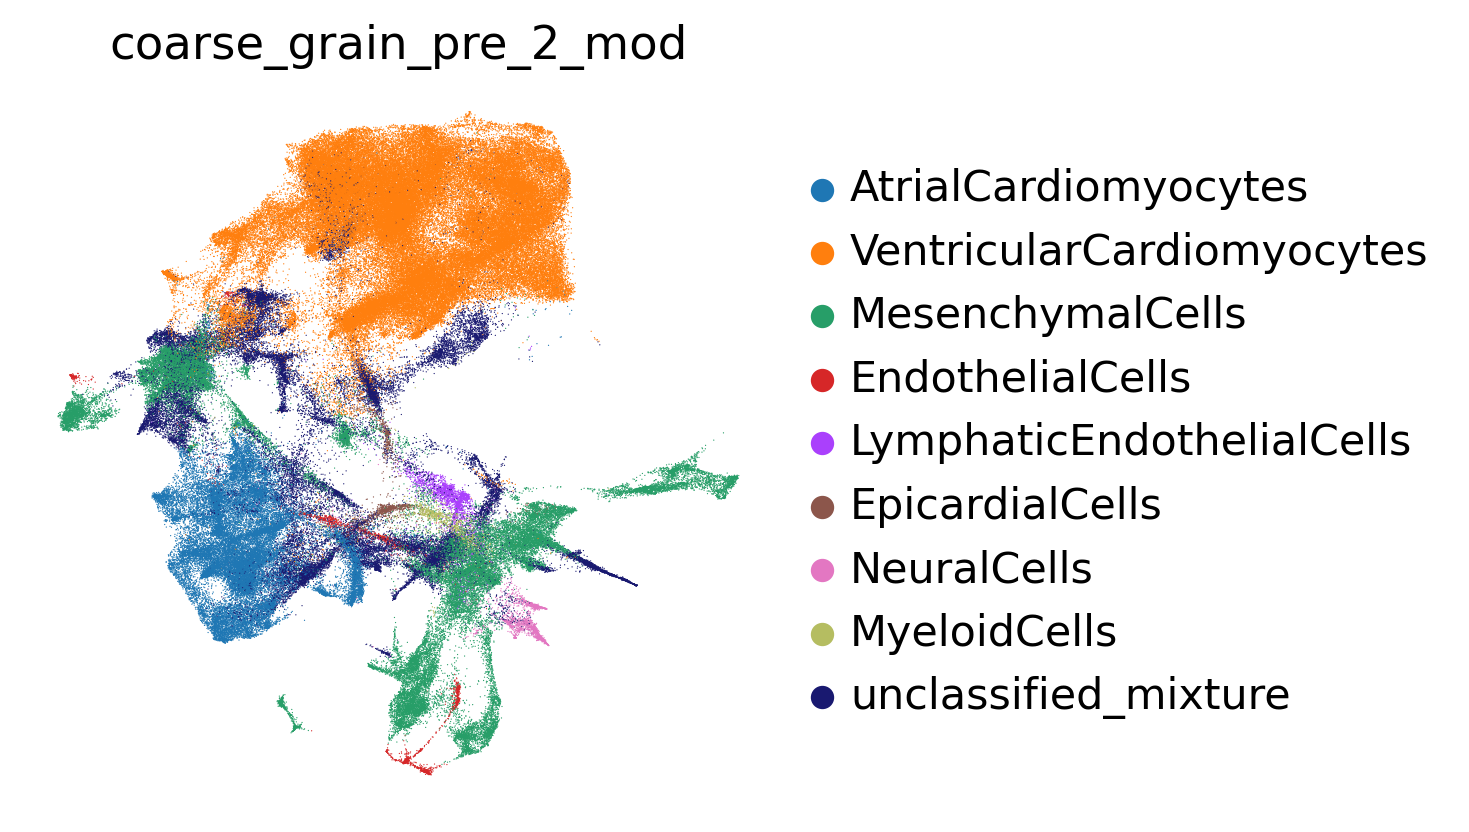

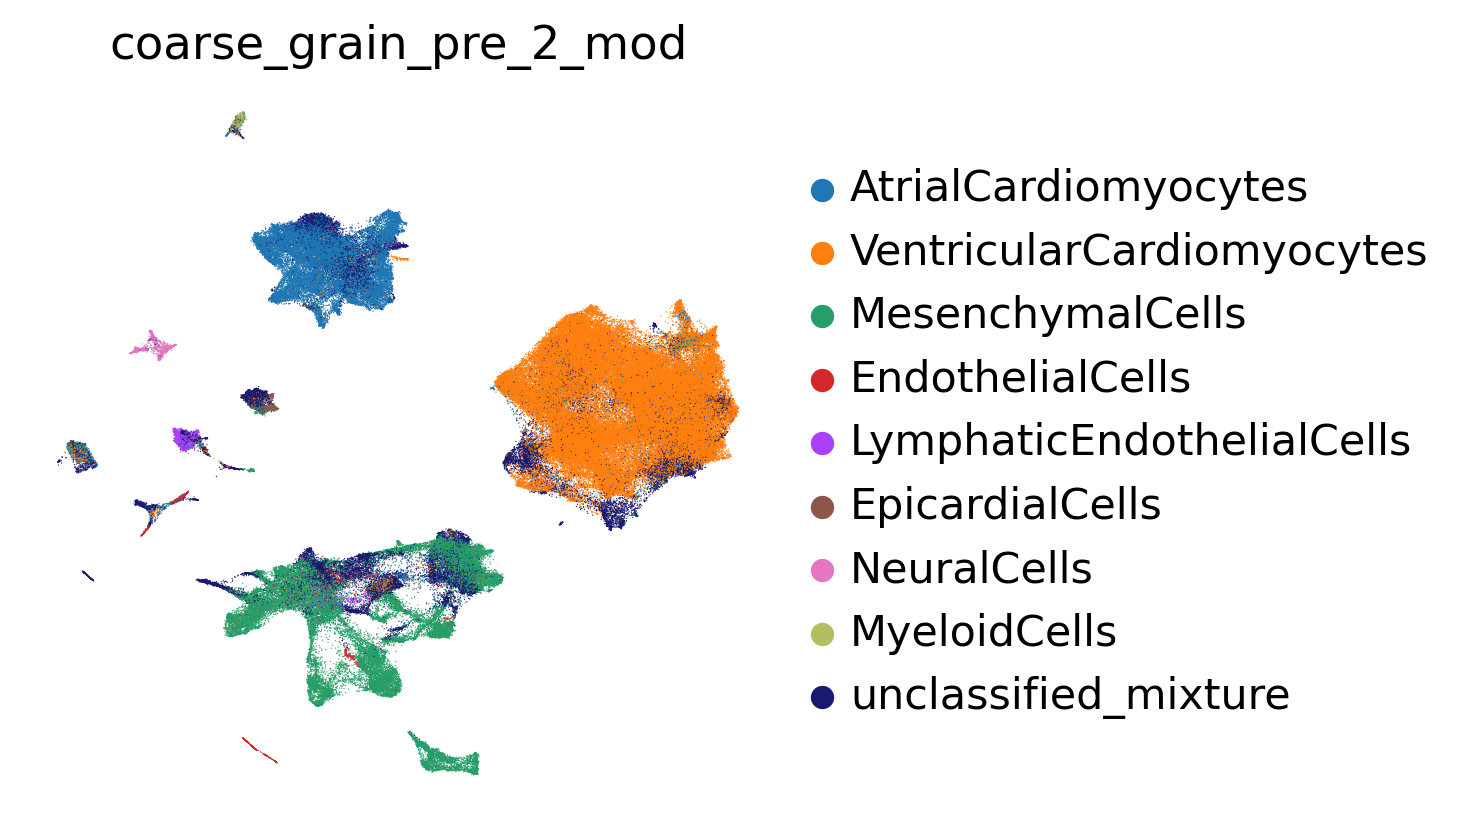

In [56]:
cats = list(adata_pre_tacco.obs['coarse_grain_pre_2_mod'].cat.categories)
colors = list(adata_pre_tacco.uns['coarse_grain_pre_2_mod_colors'])
idx = cats.index("unclassified_mixture")
colors[idx] = "midnightblue"

adata_pre_tacco.uns['coarse_grain_pre_2_mod_colors'] = colors
sc.pl.embedding(adata_pre_tacco, basis='X_umap_scVI_n-layers-3',
               color='coarse_grain_pre_2_mod',
                frameon=False, show=False)
plt.savefig(f'{figdir}/VisiumHD_pre-TACCO_UMAP_coarse_grain_pre.pdf', bbox_inches="tight",dpi=300)

adata_post_tacco.uns['coarse_grain_pre_2_mod_colors'] = colors
sc.pl.embedding(adata_post_tacco, basis='X_umap_scVI_n-layers-3',
               color='coarse_grain_pre_2_mod',
                frameon=False,show=False)
plt.savefig(f'{figdir}/VisiumHD_post-TACCO_UMAP_coarse_grain_pre.pdf', bbox_inches="tight",dpi=300)

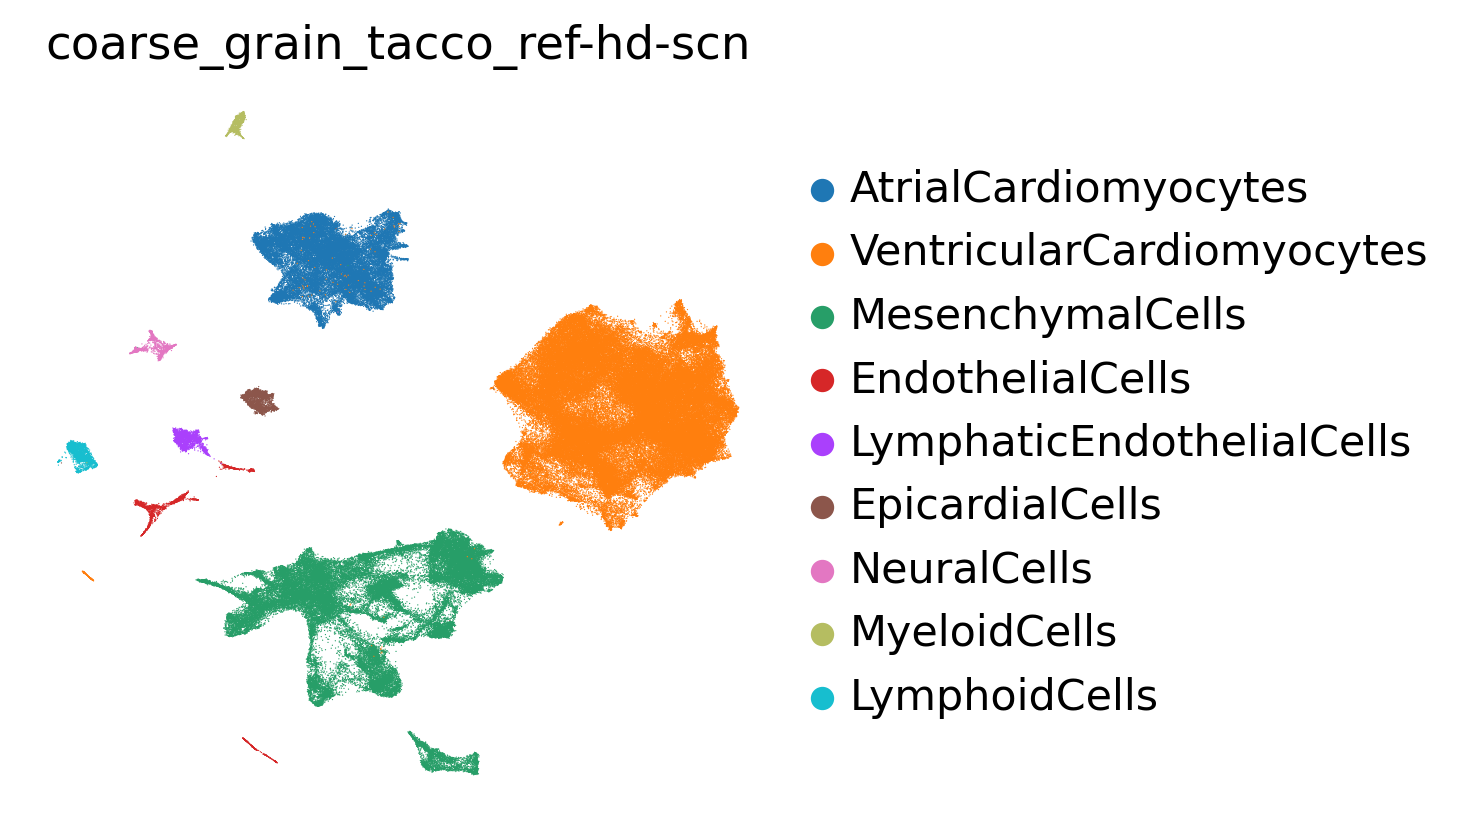

In [57]:
sc.pl.embedding(adata_post_tacco, basis='X_umap_scVI_n-layers-3',
               color='coarse_grain_tacco_ref-hd-scn',
                frameon=False,
               show=False)
plt.savefig(f'{figdir}/VisiumHD_post-TACCO_UMAP_coarse_grain_tacco.pdf', bbox_inches="tight",dpi=300)